In [1]:
import torch
from torch import nn, optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA

In [2]:
days = pd.read_csv('attack_data/all_classes_normalized.csv')
days.head()

,Label,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,ohe_port_8080,ohe_port_22,ohe_port_443,ohe_port_3389,ohe_port_445,ohe_port_0,ohe_port_other,ohe_prot_6,ohe_prot_17,ohe_prot_0
0,Benign,-0.011309,-0.024930,-0.002532,-0.022338,-0.009243,1.855494,-0.242391,1.538584,2.194835,...,0,0,0,0,0,0,0,1,0,0
1,Benign,-0.011800,-0.025854,-0.012561,-0.026478,-0.010357,-0.311832,2.457539,0.263048,-0.501696,...,0,0,0,0,0,0,0,0,1,0
2,Benign,-0.012513,-0.025854,-0.022590,-0.026899,-0.011427,-0.325549,-0.242391,-0.189561,-0.187101,...,0,0,0,0,0,0,1,1,0,0
3,Benign,-0.012512,-0.026161,-0.022590,-0.026957,-0.011075,-0.352983,1.864872,0.077890,-0.501696,...,0,0,0,0,0,0,0,0,1,0
4,Benign,-0.008773,-0.024007,0.037582,-0.017394,-0.000954,2.084115,-0.242391,2.073486,1.733593,...,0,0,0,1,0,0,0,1,0,0


In [3]:
days['Label'].value_counts()

Label
Benign                      803354
DDOS attack-HOIC            686012
DDoS attacks-LOIC-HTTP      576191
DoS attacks-Hulk            461912
Bot                         286191
FTP-BruteForce              193354
SSH-Bruteforce              187589
Infilteration               160639
DoS attacks-SlowHTTPTest    139890
DoS attacks-GoldenEye        41508
DoS attacks-Slowloris        10990
DDOS attack-LOIC-UDP          1730
Brute Force -Web               611
Brute Force -XSS               230
SQL Injection                   87
Name: count, dtype: int64

In [4]:
y_df = pd.DataFrame(days['Label'])
X_df = pd.DataFrame(days.drop(columns=['Label']))

labels_str = [i[0] for i in y_df.value_counts().index]

for i, l in enumerate(labels_str):
    y_df = y_df.replace(l, i)

y_df = pd.DataFrame(y_df)

labels_str

C:\Users\linco\AppData\Local\Temp\ipykernel_7580\661565486.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_df = y_df.replace(l, i)


['Benign',
 'DDOS attack-HOIC',
 'DDoS attacks-LOIC-HTTP',
 'DoS attacks-Hulk',
 'Bot',
 'FTP-BruteForce',
 'SSH-Bruteforce',
 'Infilteration',
 'DoS attacks-SlowHTTPTest',
 'DoS attacks-GoldenEye',
 'DoS attacks-Slowloris',
 'DDOS attack-LOIC-UDP',
 'Brute Force -Web',
 'Brute Force -XSS',
 'SQL Injection']

In [ ]:
hidden_classes = [1,2,3,4,5,8,9,10,11,12,13,14] #Classes ocultas do treinamento

hidden_classes_index = list(y_df[y_df['Label'].isin(hidden_classes)].index)

y_hidden = y_df.loc[hidden_classes_index]

y_not_hidden = y_df.drop(hidden_classes_index)

X_hidden = X_df.loc[hidden_classes_index]

X_not_hidden = X_df.drop(hidden_classes_index)

X_train, X_test, y_train, y_test = train_test_split(X_not_hidden,y_not_hidden, test_size=0.25, random_state=123)

In [6]:
torch.manual_seed(123)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

X_train = torch.tensor(np.array(X_train), dtype=torch.float)
y_train = torch.tensor(np.array(y_train), dtype=torch.float)

train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train,y_train), batch_size=512, shuffle=True)

In [7]:
def ContrastiveLoss(input1, input2, y, margin=1.0):
    # y = 0 quando input1 e input2 são da mesma classe e y = 1 caso contrário
    diff = input1 - input2
    dist_sq = torch.sum(torch.pow(diff,2),1)
    dist = torch.sqrt(dist_sq + 1e-10) # Soma 1e-10 pois se o sqrt der 0 o gradiente da NaN
    mdist = margin - dist
    mdist = torch.clamp(mdist, min=0.0)
    loss = ((1-y) * dist* dist/2) + (y * mdist * mdist/2)
    return torch.mean(loss)

def AEContrastive(input, output, batch_encoded_left, batch_encoded_right, batch_is_same, margin=1.0, lambda1=1.0):
    ae_loss = torch.mean(((output - input)**2)/(input.shape[1]))
    contrastive_loss = ContrastiveLoss(batch_encoded_left, batch_encoded_right, batch_is_same, margin=margin)
    return ae_loss + contrastive_loss * lambda1


In [8]:
class contrastive_ae(nn.Module):
    def __init__(self, input_neurons, neurons):
        super().__init__()
        self.encoder0 = nn.Linear(input_neurons,64)
        self.encoder1 = nn.Linear(64,32)
        self.encoder2 = nn.Linear(32,16)
        self.encoder3 = nn.Linear(16,neurons)

        self.decoder0 = nn.Linear(neurons,16)
        self.decoder1 = nn.Linear(16,32)
        self.decoder2 = nn.Linear(32,64)
        self.decoder3 = nn.Linear(64,input_neurons)

        self.activation0 = nn.ReLU()
    
    def forward(self, X):
        X = self.activation0(self.encoder0(X))
        X = self.activation0(self.encoder1(X))
        X = self.activation0(self.encoder2(X))
        X = self.activation0(self.encoder3(X))
        encoded = X
        X = self.activation0(self.decoder0(X))
        X = self.activation0(self.decoder1(X))
        X = self.activation0(self.decoder2(X))
        X = self.decoder3(X)

        return X, encoded

In [9]:
neurons = 15 - len(hidden_classes)
print(f'{X_train.shape[1]} {neurons}')
model = contrastive_ae(input_neurons=X_train.shape[1],neurons=neurons)
model.to(device)

opt = optim.Adam(model.parameters())
margin = 10 # Parametro de afastamento das classes
cae_lambda_1 = 0.5 # Parametro de influencia na distancia das classes

89 4


In [10]:
for epoch in range(100):
    running_loss = 0
    for data in train_loader:
        inputs, labels = data
        size = len(inputs)
        if size < 2:
            continue
        else:
            if size % 2 == 1:
                inputs = inputs[:-1]
                labels = labels[:-1]
                size -= 1
            labels = torch.reshape(labels,(-1,))
            inputs.to(device)
            labels.to(device)
            opt.zero_grad()
            outputs, encoded = model.forward(inputs)
            mid = size//2
            is_same = torch.eq(labels[:mid], labels[mid:]).int()
            y_sim = (is_same -1) * (-1)
            loss = AEContrastive(input=inputs, output=outputs, batch_encoded_left=encoded[:mid],batch_encoded_right=encoded[mid:], batch_is_same=y_sim, margin=margin, lambda1=cae_lambda_1)
            #loss = dummyMSELoss(inputs,outputs)
            loss.backward()
            opt.step()
            running_loss += loss.item()
            #print(f'loss = {loss.item()} batch_size = {size}')
    print(f'Epoch {epoch+1} loss:{running_loss/len(train_loader)}')

Epoch 1 loss:2.8558958767147273
Epoch 2 loss:2.0641167695679594
Epoch 3 loss:2.9230774032826328
Epoch 4 loss:2.0456811349200703
Epoch 5 loss:2.040455331551163
Epoch 6 loss:2.1000262170138946
Epoch 7 loss:2.0218642382017515
Epoch 8 loss:2.0111711773195706
Epoch 9 loss:2.0124367714833467
Epoch 10 loss:1.9923359583948368
Epoch 11 loss:1.9890888239684466
Epoch 12 loss:1.99012042364918
Epoch 13 loss:1.9936772811508994
Epoch 14 loss:1.9802861270261818
Epoch 15 loss:1.9825643501861094
Epoch 16 loss:1.9756393407157207
Epoch 17 loss:1.971770788404576
Epoch 18 loss:1.9690875528432432
Epoch 19 loss:1.9598000715511017
Epoch 20 loss:1.9636074152952356
Epoch 21 loss:1.9579111935688411
Epoch 22 loss:1.955950418353703
Epoch 23 loss:1.9603628286774486
Epoch 24 loss:1.9524581000088628
Epoch 25 loss:1.9486068329315476
Epoch 26 loss:1.9581468462321676
Epoch 27 loss:1.946892746942101
Epoch 28 loss:1.9523424087229304
Epoch 29 loss:1.9505091948592952
Epoch 30 loss:1.9444251106879584
Epoch 31 loss:1.952365842

In [11]:
class encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder0 = list(model.children())[0]
        self.encoder1 = list(model.children())[1]
        self.encoder2 = list(model.children())[2]
        self.encoder3 = list(model.children())[3]
        self.activation0 = list(model.children())[8]
    
    def forward(self, X):
        X = self.activation0(self.encoder0(X))
        X = self.activation0(self.encoder1(X))
        X = self.activation0(self.encoder2(X))
        X = self.activation0(self.encoder3(X))
        return X

In [12]:
model_e = encoder()
model_e.to(device)

model_e.eval()
train_encoded = model_e(X_train)

train_encoded = train_encoded.detach().cpu().numpy()

pca = PCA(n_components=2)

train_encoded_pca = pca.fit_transform(train_encoded)

train_view_df = pd.DataFrame({0:train_encoded_pca[:,0], 1:train_encoded_pca[:,1]})

train_view_df['Label'] = y_train.detach().cpu().numpy().squeeze(1).astype(int)

custom_colors = [
    "#FF5733",  # Laranja avermelhado
    "#33FF57",  # Verde claro vibrante
    "#3357FF",  # Azul vivo
    "#FFFF33",  # Amarelo forte
    "#FF33FF",  # Magenta (rosa choque)
    "#33FFFF",  # Ciano claro
    "#990000",  # Vermelho escuro
    "#009900",  # Verde escuro
    "#000099",  # Azul marinho
    "#999900",  # Amarelo amarronzado/mostarda
    "#990099",  # Roxo intenso
    "#009999",  # Verde-água escuro
    "#CCCCCC",  # Cinza claro
    "#FF6600",  # Laranja forte (tipo tangerina)
    "#6600FF",  # Roxo azulado (índigo intenso)
]
colors = {0: custom_colors[0],
          1: custom_colors[1],
          2: custom_colors[2],
          3: custom_colors[3],
          4: custom_colors[4],
          5: custom_colors[5],
          6: custom_colors[6],
          7: custom_colors[7],
          8: custom_colors[8],
          9: custom_colors[9],
          10: custom_colors[10],
          11: custom_colors[11],
          12: custom_colors[12],
          13: custom_colors[13],
          14: custom_colors[14],
          }
train_view_df['Cor'] = train_view_df['Label'].map(colors)

map_tipo = {0: labels_str[0], 
            1: labels_str[1], 
            2: labels_str[2], 
            3: labels_str[3], 
            4: labels_str[4], 
            5: labels_str[5], 
            6: labels_str[6], 
            7: labels_str[7], 
            8: labels_str[8], 
            9: labels_str[9], 
            10: labels_str[10], 
            11: labels_str[11], 
            12: labels_str[12], 
            13: labels_str[13], 
            14: labels_str[14], 
            }

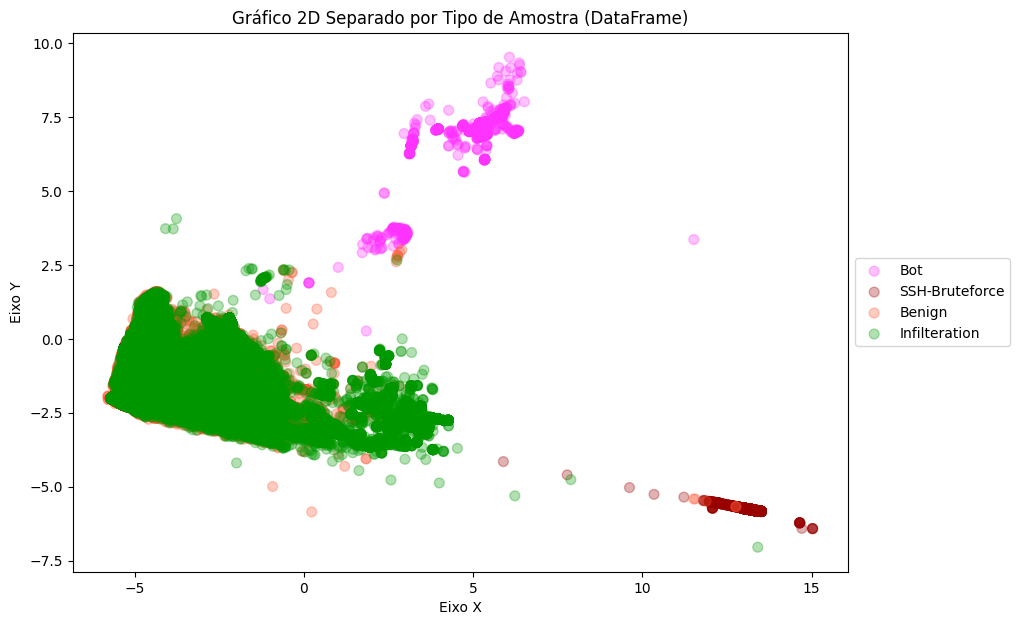

In [13]:
plt.figure(figsize=(10, 7))

for tipo in train_view_df['Label'].unique():
    subset = train_view_df[train_view_df['Label'] == tipo]
    plt.scatter(subset[0], subset[1], label=map_tipo[tipo], c=subset['Cor'], s=50, alpha=0.3)

    
plt.title('Gráfico 2D Separado por Tipo de Amostra (DataFrame)')
plt.xlabel('Eixo X')
plt.ylabel('Eixo Y')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

plt.show()

In [14]:
score = silhouette_score(train_encoded, train_view_df['Label'])
print("Silhouette Score:", score)

KeyboardInterrupt: 

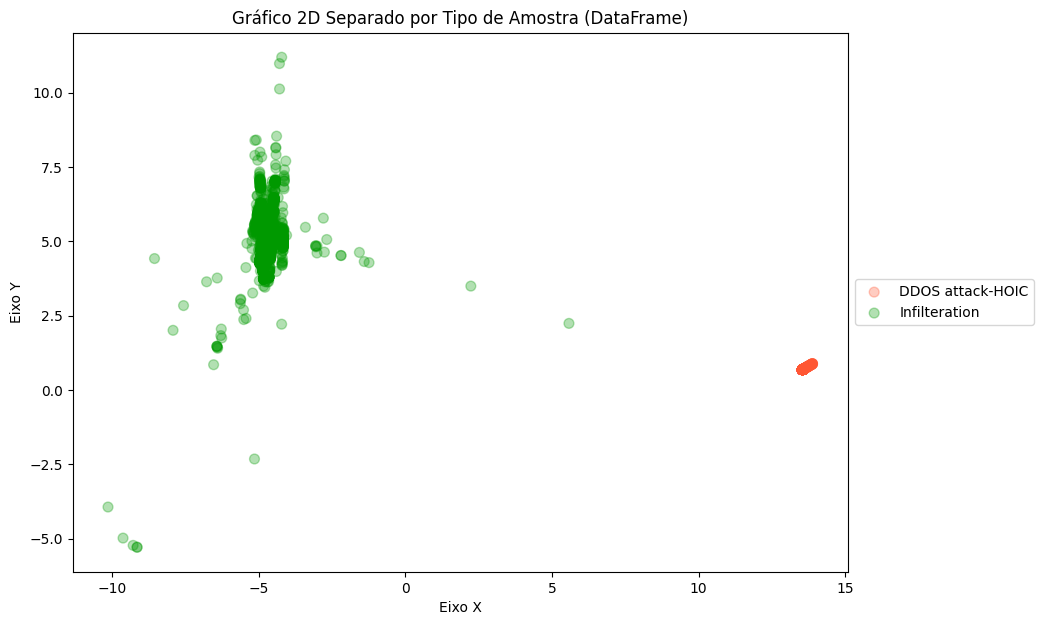

In [ ]:
plt.figure(figsize=(10, 7))

sub = [0,7]

for tipo in sub:
    subset = train_view_df[(train_view_df['Label'] == tipo) & (train_view_df[0] < 50)]
    plt.scatter(subset[0], subset[1], label=map_tipo[tipo], c=subset['Cor'], s=50, alpha=0.3)

    
plt.title('Gráfico 2D Separado por Tipo de Amostra (DataFrame)')
plt.xlabel('Eixo X')
plt.ylabel('Eixo Y')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

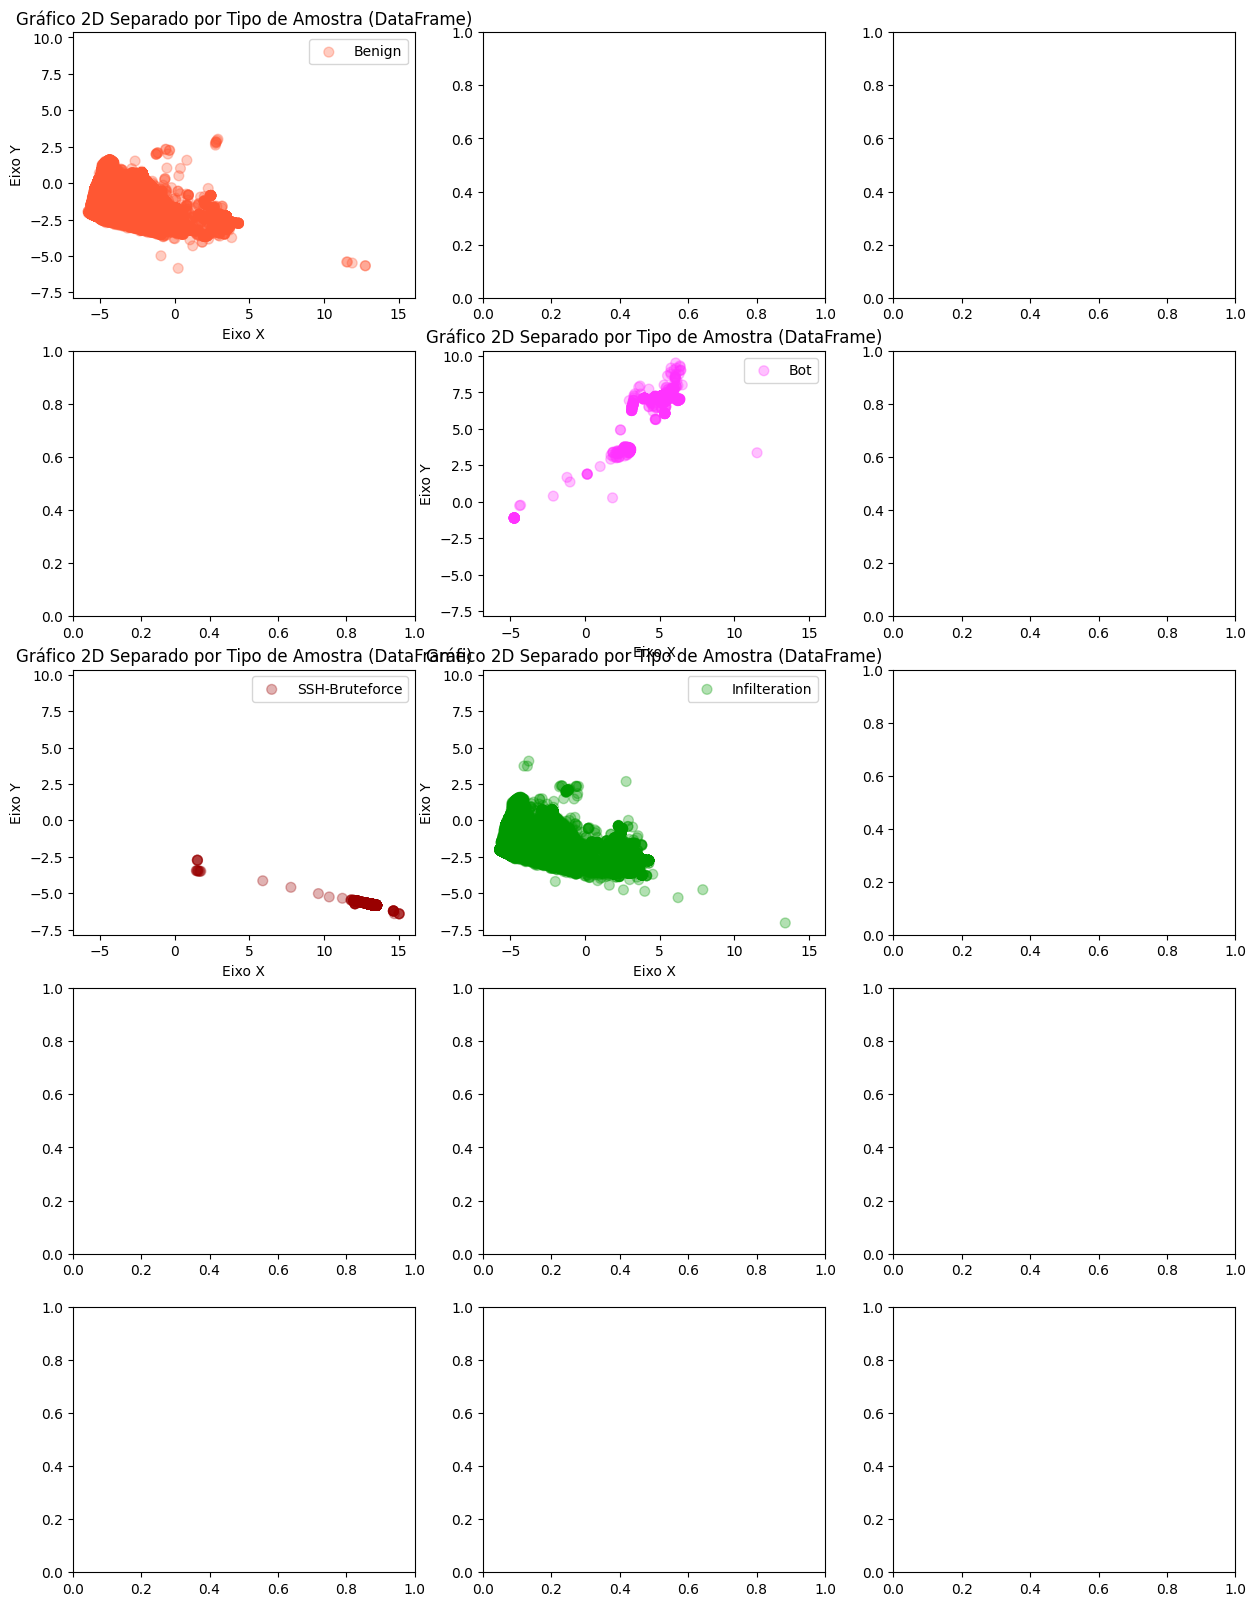

In [15]:
n_classes = len(labels_str)
n_rows = (n_classes+2)//3
fig, axs = plt.subplots(n_rows, 3, figsize=(15, 4*n_rows))

for tipo, ax in enumerate(axs.ravel()[:n_classes]):
    if tipo in train_view_df['Label'].unique():
        subset = train_view_df[(train_view_df['Label'] == tipo) & (train_view_df[0] < 50)]
    else:
        continue
        
    ax.scatter(subset[0], subset[1], label=map_tipo[tipo], c=subset['Cor'], s=50, alpha=0.3)
    ax.set_title('Gráfico 2D Separado por Tipo de Amostra (DataFrame)')
    ax.set_xlabel('Eixo X')
    ax.set_ylabel('Eixo Y')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend()

for tipo, ax in enumerate(axs.ravel()[n_classes:]):
    print(tipo)
    ax.axis('off')

plt.show()

In [ ]:
X_test = torch.tensor(np.array(X_test), dtype=torch.float)

test_encoded = model_e(X_test)

test_encoded = test_encoded.detach().cpu().numpy()

test_encoded = pca.fit_transform(test_encoded)

test_view_df = pd.DataFrame({0:test_encoded[:,0], 1:test_encoded[:,1]})

test_view_df['Label'] = y_test['Label'].values

test_view_df['Cor'] = test_view_df['Label'].map(colors)

In [ ]:
map_tipo[2]

'DDoS attacks-LOIC-HTTP'

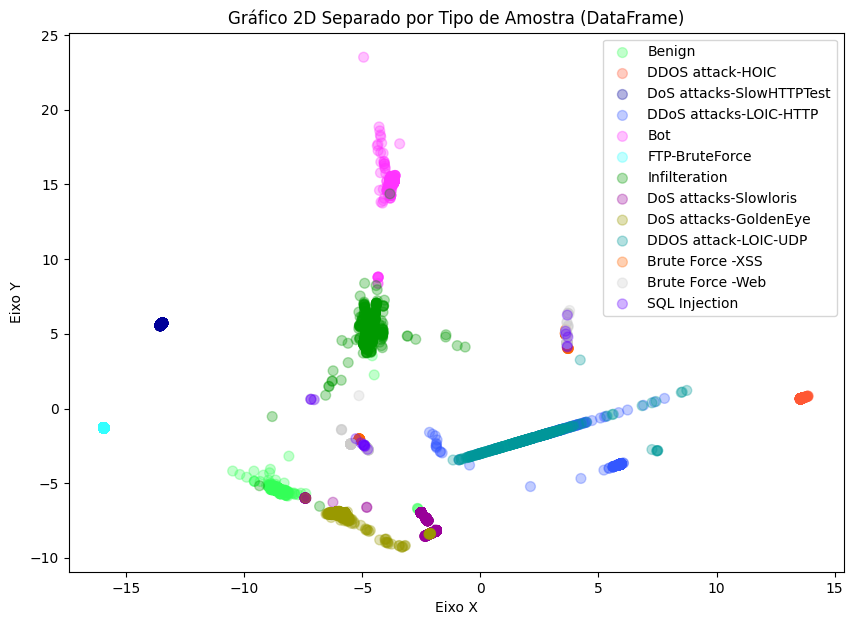

In [ ]:
plt.figure(figsize=(10, 7))

for tipo in test_view_df['Label'].unique():
    subset = test_view_df[test_view_df['Label'] == tipo]
    plt.scatter(subset[0], subset[1], label=map_tipo[tipo], c=subset['Cor'], s=50, alpha=0.3)

    
plt.title('Gráfico 2D Separado por Tipo de Amostra (DataFrame)')
plt.xlabel('Eixo X')
plt.ylabel('Eixo Y')
plt.legend()

plt.show()

In [ ]:
X_hidden = torch.tensor(np.array(X_hidden), dtype=torch.float)
hidden_encoded = model_e(X_hidden)
hidden_encoded = hidden_encoded.detach().cpu().numpy()
hidden_encoded = pca.fit_transform(hidden_encoded)
hidden_view_df = pd.DataFrame({0:hidden_encoded[:,0], 1:hidden_encoded[:,1]})
hidden_view_df['Label'] = y_hidden['Label'].values
hidden_view_df['Cor'] = hidden_view_df['Label'].map(colors)

d:\Downloads\Mestrado\Experimento_autoencoder_contrastive\contrastive_autoencoder_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


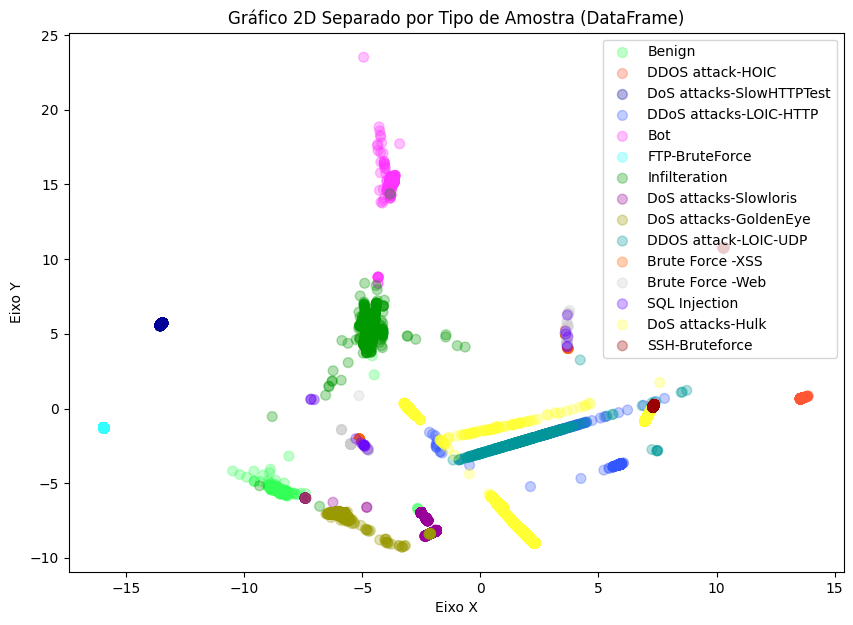

In [ ]:
plt.figure(figsize=(10, 7))

for tipo in test_view_df['Label'].unique():
    subset = test_view_df[test_view_df['Label'] == tipo]
    plt.scatter(subset[0], subset[1], label=map_tipo[tipo], c=subset['Cor'], s=50, alpha=0.3)

for tipo in hidden_view_df['Label'].unique():
    subset = hidden_view_df[hidden_view_df['Label'] == tipo]
    plt.scatter(subset[0], subset[1], label=map_tipo[tipo], c=subset['Cor'], s=50, alpha=0.3)

    
plt.title('Gráfico 2D Separado por Tipo de Amostra (DataFrame)')
plt.xlabel('Eixo X')
plt.ylabel('Eixo Y')
plt.legend()

x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

plt.show()

In [ ]:
n_classes = len(labels_str)
n_rows = (n_classes+2)//3

print(f'{n_classes} {n_rows}')

15 5


In [ ]:
test_view_df['Label'].unique()
t = 0
if t in test_view_df['Label'].unique():
    print('test')
else:
    print('hidden')

test


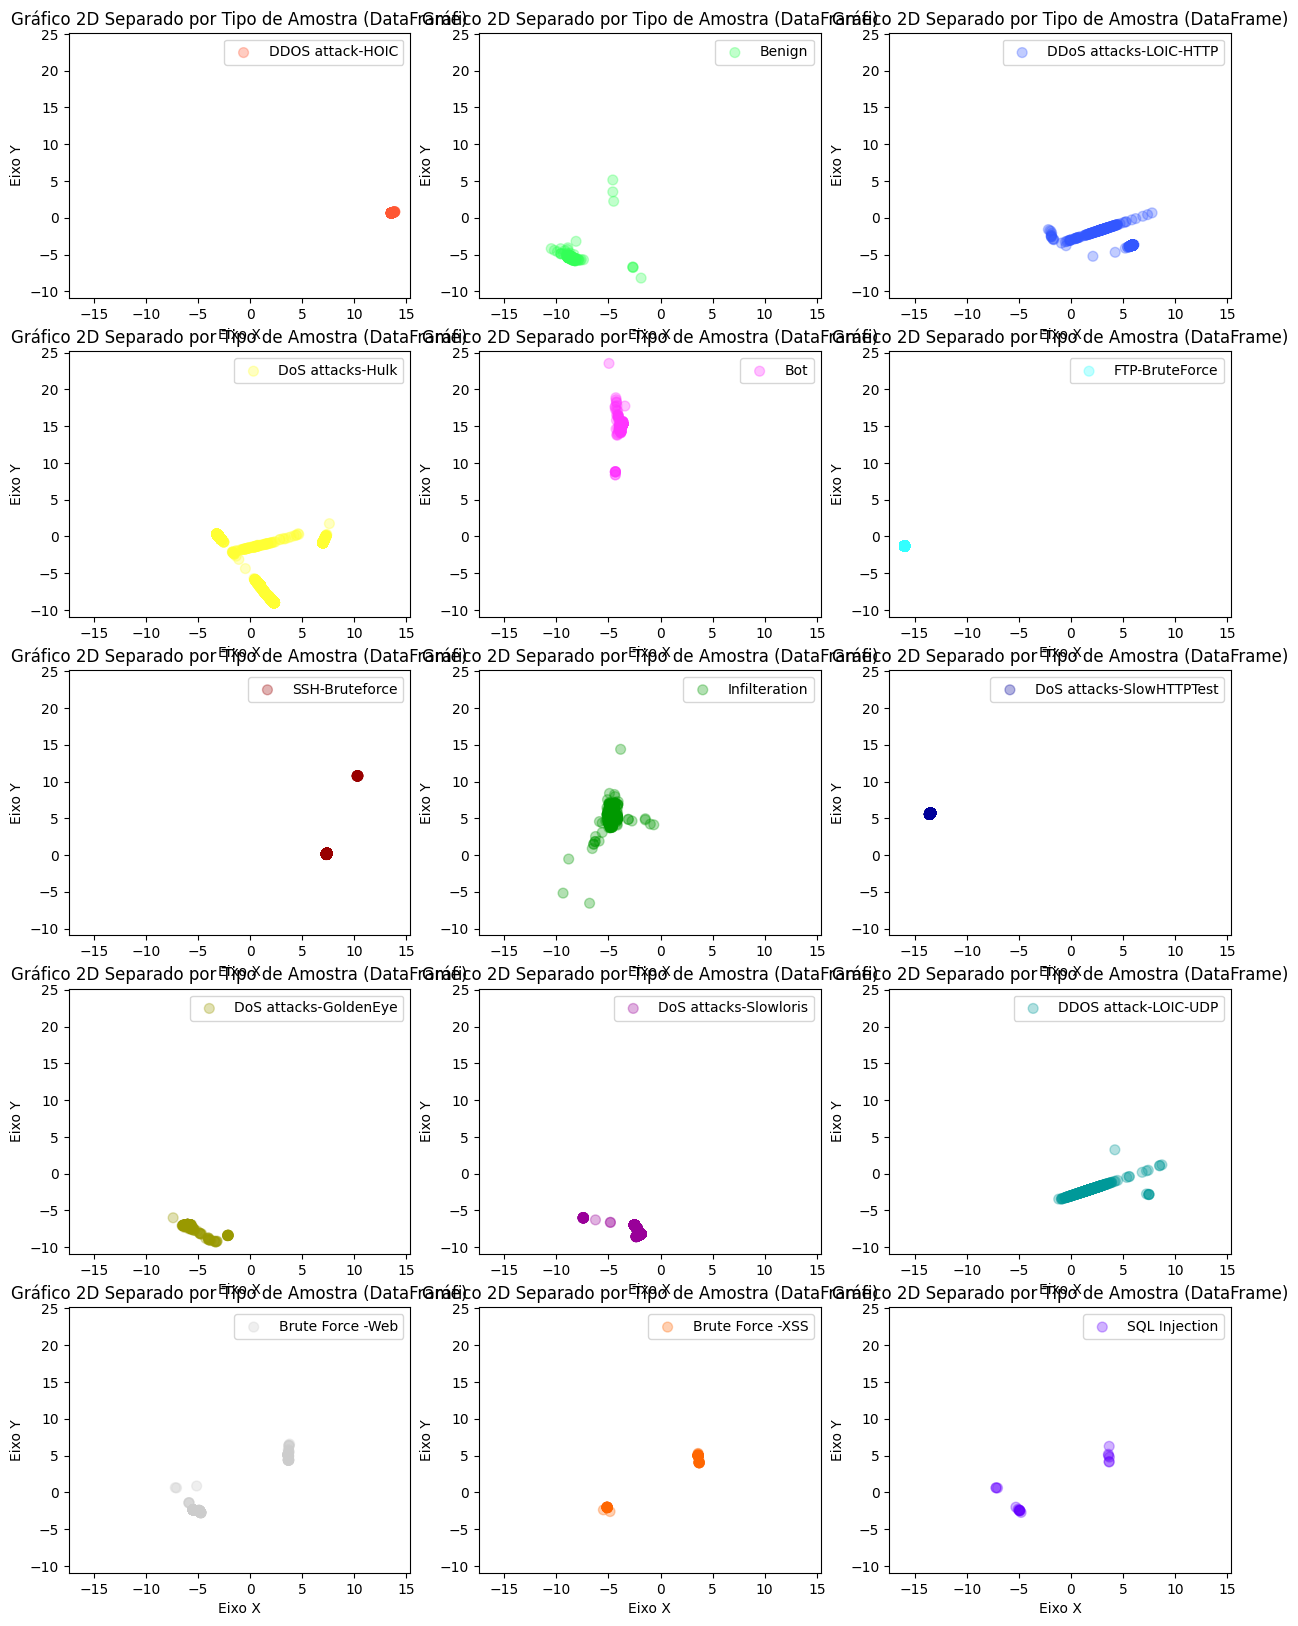

In [ ]:
n_classes = len(labels_str)
n_rows = (n_classes+2)//3
fig, axs = plt.subplots(n_rows, 3, figsize=(15, 4*n_rows))

for tipo, ax in enumerate(axs.ravel()[:n_classes]):
    if tipo in test_view_df['Label'].unique():
        subset = test_view_df[test_view_df['Label'] == tipo]
    else:
        subset = hidden_view_df[hidden_view_df['Label'] == tipo]
        
    ax.scatter(subset[0], subset[1], label=map_tipo[tipo], c=subset['Cor'], s=50, alpha=0.3)
    ax.set_title('Gráfico 2D Separado por Tipo de Amostra (DataFrame)')
    ax.set_xlabel('Eixo X')
    ax.set_ylabel('Eixo Y')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend()

for tipo, ax in enumerate(axs.ravel()[n_classes:]):
    print(tipo)
    ax.axis('off')

plt.show()